In [20]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

#import seaborn as sns
import pandas as pd
import os
import cooler
import cooltools

import cooltools.lib.plotting
from matplotlib.colors import LogNorm

In [21]:
## Analysis of 2024 MRC5 DpnII data
## Read 2024 RepHiC data



clr_rephic_hu3 = cooler.Cooler('2024-02-and-04-Rep-HiC-HU-MRC5-WT-merged-rerun.merged_sort.MAPQ.30.10k.cool')

clr_rephic_nt3 = cooler.Cooler('2024-02-and-04-Rep-HiC-UT-MRC5-WT-merged-rerun.merged_sort.MAPQ.30.10k.cool')

clr_rephic_hu_g9a3 = cooler.Cooler('2024-02-and-04-Rep-HiC-HU-MRC5-G9ai-merged.merged_sort.MAPQ.30.10k.cool')

clr_rephic_nt_g9a3 = cooler.Cooler('2024-02-and-04-Rep-HiC-UT-MRC5-G9ai-merged.merged_sort.MAPQ.30.10k.cool')

clr_hic_hu3 = cooler.Cooler('2024-02-16-HiC-HU-MRC5-WT.merged_sort.MAPQ.30.10k.cool')

clr_hic_nt3 = cooler.Cooler('2024-02-16-HiC-NT-MRC5-WT.merged_sort.MAPQ.30.10k.cool')

clr_hic_hu_g9a3 = cooler.Cooler('2025-11-12-HiC-HU-MRC5-G9ai.merged_sort.MAPQ.30.10k.cool')

clr_hic_nt_g9a3 = cooler.Cooler('2025-11-12-HiC-UT-MRC5-G9ai.merged_sort.MAPQ.30.10k.cool')

In [22]:
## 10kb and 25kb resolution combined fountain files

## Resolution and flank parameters
flank = 250_000
resolution = 10000

################Cooler file for calculating EXPECTED###############
## Read 2024 Fountain (HU+UT) combined bed file ##

rephic_ut_2 = clr_rephic_nt3
hic_ut_2 = clr_hic_nt3

rephic_hu_2 = clr_rephic_hu3
hic_hu_2 = clr_hic_hu3

rephic_hu_g9a_2 = clr_rephic_hu_g9a3
hic_hu_g9a_2 = clr_hic_hu_g9a3 

rephic_ut_g9a_2 = clr_rephic_nt_g9a3
hic_ut_g9a_2 = clr_hic_nt_g9a3 

fountain_bed = pd.read_csv('2024-02-and-04-Rep-HiC-HU-and-UT.10k-and-25k.combined.bed', sep='\t', comment='t', header=None)

fountain_bed.columns = ['chrom', 'start', 'end']
expected = cooltools.api.expected.expected_cis(hic_ut_2,
    smooth=True, aggregate_smoothed=True, smooth_sigma=0.1,
    clr_weight_name='weight',ignore_diags = 1, nproc=24)

obs_exp_pileup = cooltools.api.snipping.pileup(rephic_ut_2, fountain_bed,
                            expected_df = expected, expected_value_col='balanced.avg', 
                            flank = flank, min_diag=1, clr_weight_name='weight', nproc=24)

mtx5 = np.nanmean(obs_exp_pileup, axis=0)

del expected,obs_exp_pileup

expected = cooltools.api.expected.expected_cis(hic_hu_2,
    smooth=True, aggregate_smoothed=True, smooth_sigma=0.1,
    clr_weight_name='weight',ignore_diags = 1, nproc=24)

obs_exp_pileup = cooltools.api.snipping.pileup(rephic_hu_2, fountain_bed,
                            expected_df = expected, expected_value_col='balanced.avg', 
                            flank = flank, min_diag=0, clr_weight_name='weight', nproc=24)

mtx7 = np.nanmean(obs_exp_pileup, axis=0)

del expected,obs_exp_pileup

expected = cooltools.api.expected.expected_cis(hic_hu_g9a_2,
    smooth=True, aggregate_smoothed=True, smooth_sigma=0.1,
    clr_weight_name='weight',ignore_diags = 1, nproc=24)

obs_exp_pileup = cooltools.api.snipping.pileup(rephic_hu_g9a_2, fountain_bed,
                            expected_df = expected, expected_value_col='balanced.avg', 
                            flank = flank, min_diag=0, clr_weight_name='weight', nproc=24)

mtx9 = np.nanmean(obs_exp_pileup, axis=0)

del expected,obs_exp_pileup

expected = cooltools.api.expected.expected_cis(hic_ut_g9a_2,
    smooth=True, aggregate_smoothed=True, smooth_sigma=0.1,
    clr_weight_name='weight',ignore_diags = 1, nproc=24)

obs_exp_pileup = cooltools.api.snipping.pileup(rephic_ut_g9a_2, fountain_bed,
                            expected_df = expected, expected_value_col='balanced.avg', 
                            flank = flank, min_diag=0, clr_weight_name='weight', nproc=24)

mtx11 = np.nanmean(obs_exp_pileup, axis=0)

del expected,obs_exp_pileup

del rephic_ut_2,hic_ut_2,rephic_hu_2,hic_hu_2,rephic_hu_g9a_2,hic_hu_g9a_2,fountain_bed

INFO:root:creating a Pool of 24 workers
INFO:root:creating a Pool of 24 workers
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3732/2215989919.py:33: RuntimeWarning: Mean of empty slice
  mtx5 = np.nanmean(obs_exp_pileup, axis=0)
INFO:root:creating a Pool of 24 workers
INFO:root:creating a Pool of 24 workers
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3732/2215989919.py:45: RuntimeWarning: Mean of empty slice
  mtx7 = np.nanmean(obs_exp_pileup, axis=0)
INFO:root:creating a Pool of 24 workers
INFO:root:creating a Pool of 24 workers
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3732/2215989919.py:57: RuntimeWarning: Mean of empty slice
  mtx9 = np.nanmean(obs_exp_pileup, axis=0)
INFO:root:creating a Pool of 24 workers
INFO:root:creating a Pool of 24 workers
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3732/2215989919.py:69: RuntimeWarning: Mean of empty slice
  mtx11 = np.nanmean(obs_exp_pileup, axis=0)


In [24]:
np.savetxt("../fig_1/UT_fountain.csv", mtx5, delimiter=",")
np.savetxt("../fig_1/HU_fountain.csv", mtx7, delimiter=",")
np.savetxt("../fig_1/HU+G9ai_fountain.csv", mtx9, delimiter=",")
np.savetxt("../fig_1/UT+G9ai_fountain.csv", mtx11, delimiter=",")

/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3732/520392702.py:87: RuntimeWarning: invalid value encountered in log2
  np.log2(mtx7-mtx5),
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3732/520392702.py:106: RuntimeWarning: invalid value encountered in log2
  np.log2(mtx7-mtx9),
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3732/520392702.py:125: RuntimeWarning: invalid value encountered in log2
  np.log2(mtx5-mtx9),
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3732/520392702.py:144: RuntimeWarning: invalid value encountered in log2
  np.log2(mtx11-mtx9),
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTo

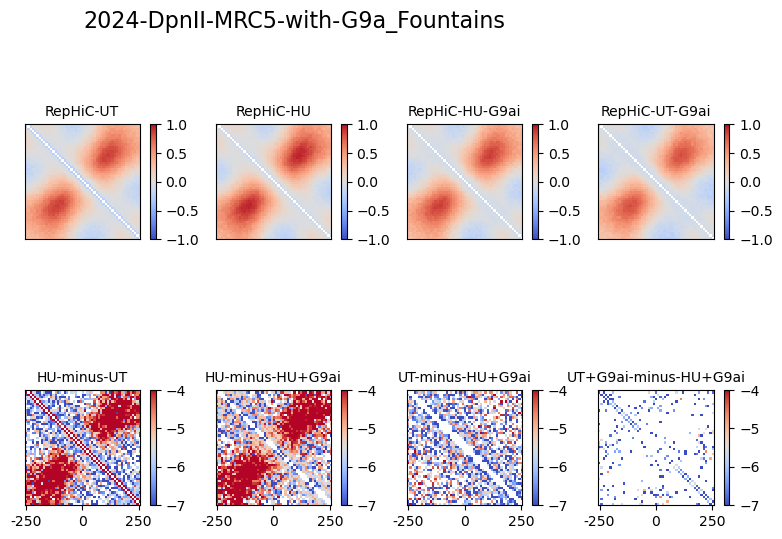

In [19]:
## 2024-Rep-HiC-MRC5 RepHiC UT, HU and G9a panels only
## We show RepHiC UT, HU and HU+G9ai along with the difference plot

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')

f, axs = plt.subplots(ncols=4, nrows=2,
    figsize=(6, 6))

plt.subplots_adjust(bottom=0.3, top=0.7, hspace=0.3, wspace=0.6)

def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

ax = axs[0,0]
im = ax.matshow(
    np.log2(mtx5),
    vmin = -1,
    vmax = 1,
    cmap='coolwarm',
    interpolation='none')


ax.set_title('RepHiC-UT', fontsize=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ax.set_xticks([])
ax.set_yticks([])

ax = axs[0,1]
im = ax.matshow(
    np.log2(mtx7),
    vmin = -1,
    vmax = 1,
    cmap='coolwarm',
    interpolation='none')


ax.set_title('RepHiC-HU', fontsize=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ax.set_xticks([])
ax.set_yticks([])

ax = axs[0,2]
im = ax.matshow(
    np.log2(mtx9),
    vmin = -1,
    vmax = 1,
    cmap='coolwarm',
    interpolation='none')

ax.set_title('RepHiC-HU-G9ai', fontsize=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ax.set_xticks([])
ax.set_yticks([])

ax = axs[0,3]
im = ax.matshow(
    np.log2(mtx11),
    vmin = -1,
    vmax = 1,
    cmap='coolwarm',
    interpolation='none')

ax.set_title('RepHiC-UT-G9ai', fontsize=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ax.set_xticks([])
ax.set_yticks([])

ax = axs[1,0]
im = ax.matshow(
    np.log2(mtx7-mtx5),
    vmin = -7,
    vmax = -4,
    cmap='coolwarm',
    interpolation='none')

ax.set_title('HU-minus-UT', fontsize=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ticks_pixels = np.linspace(0, flank*2//resolution,3)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(ticks_pixels)
ax.set_xticklabels(ticks_kbp)
ax.set_yticks([])

ax = axs[1,1]
im = ax.matshow(
    np.log2(mtx7-mtx9),
    vmin = -7,
    vmax = -4,
    cmap='coolwarm',
    interpolation='none')

ax.set_title('HU-minus-HU+G9ai', fontsize=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ticks_pixels = np.linspace(0, flank*2//resolution,3)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(ticks_pixels)
ax.set_xticklabels(ticks_kbp)
ax.set_yticks([])

ax = axs[1,2]
im = ax.matshow(
    np.log2(mtx5-mtx9),
    vmin = -7,
    vmax = -4,
    cmap='coolwarm',
    interpolation='none')

ax.set_title('UT-minus-HU+G9ai', fontsize=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ticks_pixels = np.linspace(0, flank*2//resolution,3)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(ticks_pixels)
ax.set_xticklabels(ticks_kbp)
ax.set_yticks([])

ax = axs[1,3]
im = ax.matshow(
    np.log2(mtx11-mtx9),
    vmin = -7,
    vmax = -4,
    cmap='coolwarm',
    interpolation='none')

ax.set_title('UT+G9ai-minus-HU+G9ai', fontsize=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ticks_pixels = np.linspace(0, flank*2//resolution,3)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(ticks_pixels)
ax.set_xticklabels(ticks_kbp)
ax.set_yticks([])

f.suptitle(f"2024-DpnII-MRC5-with-G9a_Fountains", fontsize=16)
f.tight_layout(rect=[0, 0, 1.3, 1])

plt.savefig('../fig_1/2024-02-and-04-Rep-HiC-HU-and-UT.10k-and-25k.combined.aggregate.Fountains-with-G9a.v2.pdf',
            bbox_inches='tight', dpi=1200, format = 'pdf')

plt.show()

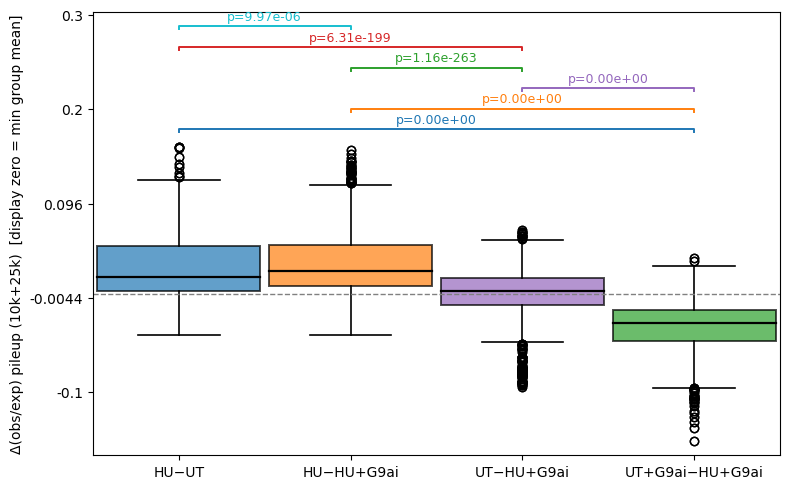

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import ttest_ind

def flat_valid(m):
    a = np.asarray(m, float).ravel()
    return a[np.isfinite(a)]

# ------ contrasts (unchanged) ------
v1 = flat_valid(mtx7  - mtx5)    # HU − UT
v2 = flat_valid(mtx7  - mtx9)    # HU − HU+G9ai
v3 = flat_valid(mtx5  - mtx9)    # UT − HU+G9ai
v4 = flat_valid(mtx11  - mtx9)   # HU+G9ai − UT+G9ai

data   = [v1, v2, v3, v4]
labels = ["HU−UT", "HU−HU+G9ai", "UT−HU+G9ai", "UT+G9ai−HU+G9ai"]

df = pd.DataFrame({
    "HU_minus_UT"        : v1,  # mtx7 - mtx5
    "HU_minus_HU_G9ai"   : v2,  # mtx7 - mtx9
    "UT_minus_HU_G9ai"   : v3,  # mtx5 - mtx9
    "HU_G9ai_minus_UT_G9ai": v4 # mtx9 - mtx11
})

# saves all four columns in the same Excel file / same sheet
df.to_excel("../fig_1/matrix_fountain_aggr.xlsx", index=False)

# ------ find offset but DON'T modify data ------
means  = [np.mean(v) for v in data]
offset = means[2]  # this mean should appear as 0 on the axis

# ------ colors ------
colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#2ca02c"]

# ------ p-values on RAW data (no shifting) ------
pairs = []
for i in range(4):
    for j in range(i+1, 4):
        _, p = ttest_ind(data[i], data[j], equal_var=False)
        pairs.append(((i+1, j+1), p))  # 1-based positions

# ------ limits & bracket start from GLOBAL max of RAW data ------
all_vals = np.concatenate(data)
gmin = float(np.nanmin(all_vals))
gmax = float(np.nanmax(all_vals))
span = max(gmax - gmin, 1e-9)

ymin = gmin - 0.05*span
ymax = gmax + 0.15*span

br_start = gmax + 0.05*span
br_step  = 0.07*span
top_needed = br_start + (len(pairs)-1)*br_step + 0.06*span
ymax = max(ymax, top_needed)

# ------ plot ------
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data, labels=labels, widths=0.95, patch_artist=True, showfliers=True)

# color boxes
for box, c in zip(bp["boxes"], colors):
    box.set_facecolor(c); box.set_alpha(0.7)
    box.set_edgecolor("black"); box.set_linewidth(1.4)
for med in bp["medians"]:
    med.set_color("black"); med.set_linewidth(1.6)
for w in bp["whiskers"]:
    w.set_color("black"); w.set_linewidth(1.2)
for cap in bp["caps"]:
    cap.set_color("black"); cap.set_linewidth(1.2)

# axis limits
ax.set_ylim(ymin, ymax)

# dotted baseline at the OFFSET (will be labeled as 0)
ax.axhline(offset, ls="--", lw=1, color="gray")

# y-tick formatter to DISPLAY values relative to offset (no data change)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{(y - offset):.2g}"))
ax.set_ylabel("Δ(obs/exp) pileup (10k+25k)  [display zero = min group mean]")

# colored brackets & labels
bracket_colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#2ca02c", "#d62728", "#17becf"]
for k, ((x1, x2), p) in enumerate(sorted(pairs, key=lambda x: x[1])):  # smallest p on top
    c = bracket_colors[k % len(bracket_colors)]
    y = br_start + k*br_step
    ax.plot([x1, x1, x2, x2], [y, y+0.01*span, y+0.01*span, y], color=c, lw=1.4)
    ax.text((x1+x2)/2, y+0.02*span, f"p={p:.2e}", ha="center", va="bottom", fontsize=9, color=c)

plt.tight_layout()
plt.savefig("../fig_1/fountain_boxplot_all.svg", dpi=1200)
plt.show()


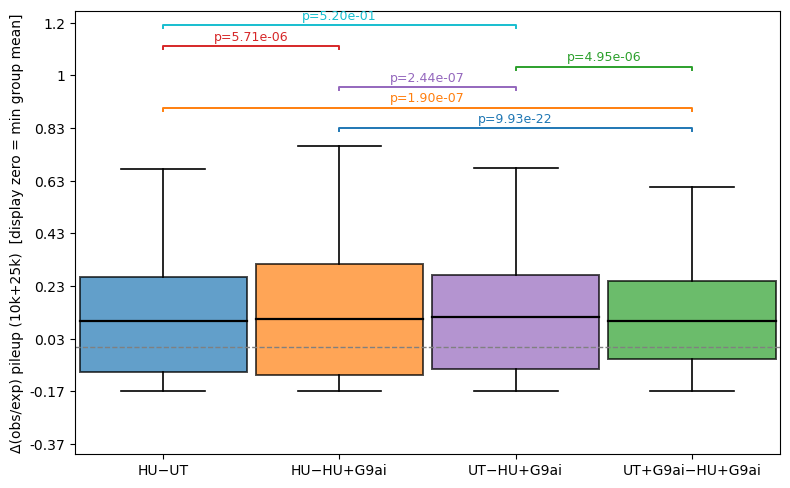

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import ttest_ind

def flat_valid(m):
    a = np.asarray(m, float).ravel()
    return a[np.isfinite(a)]

# ------ contrasts (unchanged) ------
v1 = flat_valid(mtx5)    # HU − UT
v2 = flat_valid(mtx7)    # HU − HU+G9ai
v3 = flat_valid(mtx9)    # UT − HU+G9ai
v4 = flat_valid(mtx11)   # HU+G9ai − UT+G9ai

data   = [v1, v2, v3, v4]
data_new = [[x for x in row if x > 1] for row in data]
labels = ["HU−UT", "HU−HU+G9ai", "UT−HU+G9ai", "UT+G9ai−HU+G9ai"]

df = pd.DataFrame({
    "HU_minus_UT"        : v1,  # mtx7 - mtx5
    "HU_minus_HU_G9ai"   : v2,  # mtx7 - mtx9
    "UT_minus_HU_G9ai"   : v3,  # mtx5 - mtx9
    "HU_G9ai_minus_UT_G9ai": v4 # mtx9 - mtx11
})

# saves all four columns in the same Excel file / same sheet
df.to_excel("../fig_1/matrix_fountain_aggr.xlsx", index=False)

# ------ find offset but DON'T modify data ------
means  = [np.mean(v) for v in data]
offset = means[2]  # this mean should appear as 0 on the axis

# ------ colors ------
colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#2ca02c"]

# ------ p-values on RAW data (no shifting) ------
pairs = []
for i in range(4):
    for j in range(i+1, 4):
        _, p = ttest_ind(data[i], data[j], equal_var=False)
        pairs.append(((i+1, j+1), p))  # 1-based positions

# ------ limits & bracket start from GLOBAL max of RAW data ------
all_vals = np.concatenate(data)
gmin = float(np.nanmin(all_vals))
gmax = float(np.nanmax(all_vals))
span = max(gmax - gmin, 1e-9)

ymin = gmin - 0.05*span
ymax = gmax + 0.15*span

br_start = gmax + 0.05*span
br_step  = 0.07*span
top_needed = br_start + (len(pairs)-1)*br_step + 0.06*span
ymax = max(ymax, top_needed)

# ------ plot ------
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data_new, labels=labels, widths=0.95, patch_artist=True, showfliers=True)

# color boxes
for box, c in zip(bp["boxes"], colors):
    box.set_facecolor(c); box.set_alpha(0.7)
    box.set_edgecolor("black"); box.set_linewidth(1.4)
for med in bp["medians"]:
    med.set_color("black"); med.set_linewidth(1.6)
for w in bp["whiskers"]:
    w.set_color("black"); w.set_linewidth(1.2)
for cap in bp["caps"]:
    cap.set_color("black"); cap.set_linewidth(1.2)

# axis limits
ax.set_ylim(ymin, ymax)

# dotted baseline at the OFFSET (will be labeled as 0)
ax.axhline(offset, ls="--", lw=1, color="gray")

# y-tick formatter to DISPLAY values relative to offset (no data change)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{(y - offset):.2g}"))
ax.set_ylabel("Δ(obs/exp) pileup (10k+25k)  [display zero = min group mean]")

# colored brackets & labels
bracket_colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#2ca02c", "#d62728", "#17becf"]
for k, ((x1, x2), p) in enumerate(sorted(pairs, key=lambda x: x[1])):  # smallest p on top
    c = bracket_colors[k % len(bracket_colors)]
    y = br_start + k*br_step
    ax.plot([x1, x1, x2, x2], [y, y+0.01*span, y+0.01*span, y], color=c, lw=1.4)
    ax.text((x1+x2)/2, y+0.02*span, f"p={p:.2e}", ha="center", va="bottom", fontsize=9, color=c)

plt.tight_layout()
plt.savefig("../fig_1/fountain_boxplot_all.svg", dpi=1200)
plt.show()


In [12]:
mtx11

array([[       nan, 0.9557832 , 0.96680712, ..., 1.1483574 , 1.16084466,
        1.1986874 ],
       [0.9557832 ,        nan, 0.95285756, ..., 1.21096405, 1.21205129,
        1.1958068 ],
       [0.96680712, 0.95285756,        nan, ..., 1.23108249, 1.19849924,
        1.16449901],
       ...,
       [1.1483574 , 1.21096405, 1.23108249, ...,        nan, 0.95997477,
        0.9862521 ],
       [1.16084466, 1.21205129, 1.19849924, ..., 0.95997477,        nan,
        0.95151337],
       [1.1986874 , 1.1958068 , 1.16449901, ..., 0.9862521 , 0.95151337,
               nan]])